In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os  # <--- This is the one it was missing!
from scipy import stats

# Now the rest of your code will work
file_path = os.path.join('..', 'data', 'kenya.csv')
df = pd.read_csv(file_path)
df['Country'] = 'Kenya'

# Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-01,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,1
2015-01-02,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,1
2015-01-03,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,1
2015-01-04,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,1
2015-01-05,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,1


In [2]:
# Check for missing values
print("Missing Values Check:")
print(df.isnull().sum())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe())

Missing Values Check:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Month          0
dtype: int64

Statistical Summary:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,6.423564
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,3.477046
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,12.000000


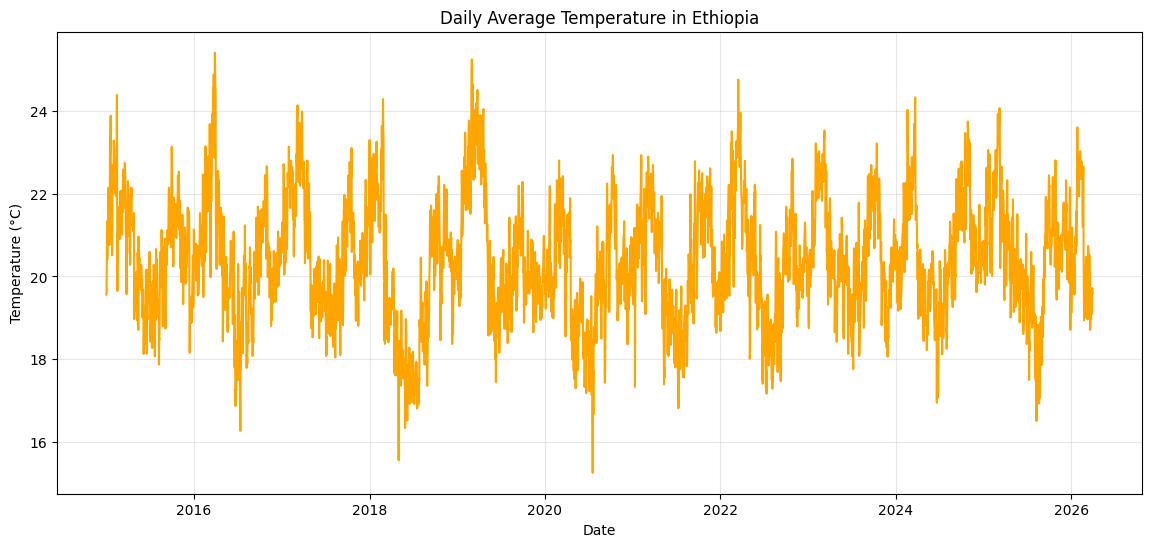

In [3]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='T2M', color='orange')
plt.title('Daily Average Temperature in Ethiopia')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

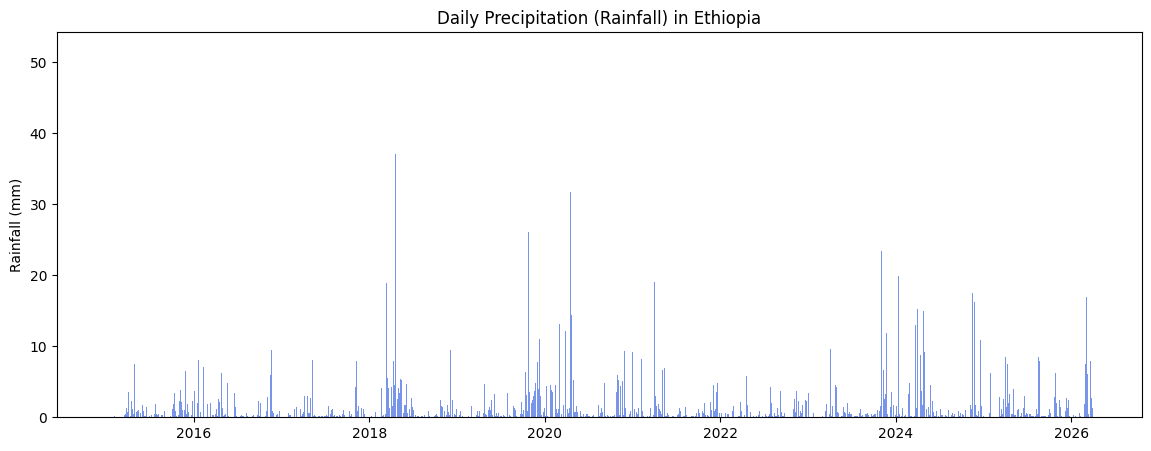

In [4]:
plt.figure(figsize=(14, 5))
plt.bar(df.index, df['PRECTOTCORR'], color='royalblue', alpha=0.7)
plt.title('Daily Precipitation (Rainfall) in Ethiopia')
plt.ylabel('Rainfall (mm)')
plt.show()

In [5]:
plt.figure(figsize=(12, 10))
# We calculate the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Weather Variable Correlations')
plt.show()

ValueError: could not convert string to float: 'Kenya'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
import numpy as np
from scipy import stats

# 1. Load and add Country column
df = pd.read_csv('../data/ethiopia.csv')
df['Country'] = 'Ethiopia'

# 2. Convert YEAR/DOY to Date and extract Month
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df.set_index('Date', inplace=True)

# 3. Handle NASA Sentinel values (-999)
df.replace(-999, np.nan, inplace=True)

# 4. Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicates found: {duplicates}")
df.drop_duplicates(inplace=True)

# 5. Missing value report
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Values Percentage:")
print(missing_pct)

In [ ]:
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))

# Flagging rows where Z > 3
outliers = (z_scores > 3).all(axis=1)
print(f"Number of outlier rows flagged: {outliers.sum()}")

# Decision: We will retain them for now as weather extremes (like the 80mm rain) 
# are important for climate study, but we acknowledge them.

In [ ]:
# Histogram of Rainfall (Log scale)
plt.figure(figsize=(10, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.show()

# Bubble Chart: Temp vs Humidity (Size = Rain)
plt.figure(figsize=(12, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.4, c=df['PRECTOTCORR'], cmap='viridis')
plt.colorbar(label='Precipitation (mm)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.title('Temp vs Humidity (Bubble size = Rainfall)')
plt.show()

In [ ]:
# Create the directory if it doesn't exist
os.makedirs('../data', exist_ok=True)

# Export
df.to_csv('../data/ethiopia_clean.csv')
print("Cleaned data exported to data/ethiopia_clean.csv")